In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("../data/base1_reviews/sentiment_labelled_sentences.csv")
df["target"] = (df["class"] == "positive").astype(int)

contagem_classes = df.groupby("target")["target"].count()
print(contagem_classes / contagem_classes.sum() * 100)

target
0    50.0
1    50.0
Name: target, dtype: float64


In [3]:
X = df["sentence"]
y = df["target"]

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("Desenvolvimento:", X_dev.shape, " Teste:", X_test.shape)

validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Desenvolvimento: (2250,)  Teste: (750,)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", MultinomialNB()),
])

parametros_nb = {
    "tfidf__max_features": [300, 500, 1000, 1500, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__alpha": [0.1, 0.5, 1.0, 2.0],
}

busca_nb = RandomizedSearchCV(
    pipe_nb, parametros_nb, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_nb.fit(X_dev, y_dev)

print("Naive Bayes - melhores hiperparâmetros:", busca_nb.best_params_)
print("Naive Bayes - F1 médio na validação:", round(busca_nb.best_score_, 4))

Naive Bayes — melhores hiperparâmetros: {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 1500, 'clf__alpha': 1.0}
Naive Bayes — F1 médio na validação: 0.81


In [5]:
from sklearn.linear_model import LogisticRegression

pipe_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

parametros_logreg = {
    "tfidf__max_features": [300, 500, 1000, 1500, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 0.3, 1, 3, 10],
}

busca_logreg = RandomizedSearchCV(
    pipe_logreg, parametros_logreg, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_logreg.fit(X_dev, y_dev)

print("Regressão Logística — melhores hiperparâmetros:", busca_logreg.best_params_)
print("Regressão Logística — F1 médio na validação:", round(busca_logreg.best_score_, 4))

Regressão Logística — melhores hiperparâmetros: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 2000, 'clf__C': 3}
Regressão Logística — F1 médio na validação: 0.8051


In [6]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

parametros_rf = {
    "tfidf__max_features": [500, 1000, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [None, 20, 30],
    "clf__min_samples_leaf": [1, 2, 4],
}

busca_rf = RandomizedSearchCV(
    pipe_rf, parametros_rf, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_rf.fit(X_dev, y_dev)

print("Random Forest — melhores hiperparâmetros:", busca_rf.best_params_)
print("Random Forest — F1 médio na validação:", round(busca_rf.best_score_, 4))

Random Forest — melhores hiperparâmetros: {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 2000, 'clf__n_estimators': 300, 'clf__min_samples_leaf': 4, 'clf__max_depth': 20}
Random Forest — F1 médio na validação: 0.7624


In [7]:
resultados = {
    "Naive Bayes": busca_nb,
    "Regressão Logística": busca_logreg,
    "Random Forest": busca_rf,
}
for nome, busca in resultados.items():
    print(f"{nome:22s} F1 médio (validação) = {busca.best_score_:.4f}")

melhor_nome = max(resultados, key=lambda k: resultados[k].best_score_)
melhor_modelo = resultados[melhor_nome].best_estimator_
print(f"\nModelo selecionado: {melhor_nome}")

Naive Bayes            F1 médio (validação) = 0.8100
Regressão Logística    F1 médio (validação) = 0.8051
Random Forest          F1 médio (validação) = 0.7624

Modelo selecionado: Naive Bayes


Acurácia:  0.8133
Precisão:  0.8117
Recall:    0.8160
F1-score:  0.8138
AUC-ROC:            0.8944
AUC-PR (trapézio):   0.9040
Average Precision:   0.9041


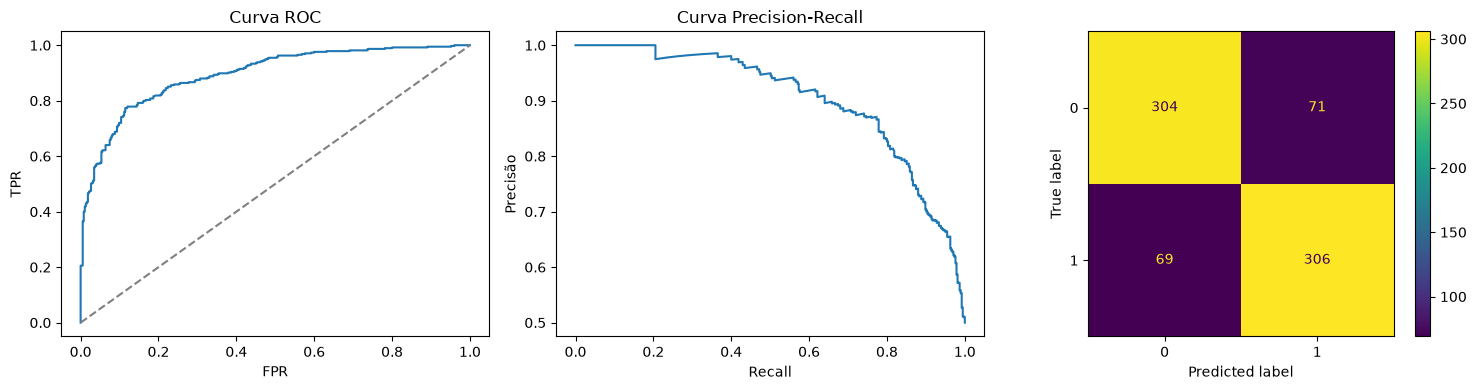

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    average_precision_score, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

y_pred = melhor_modelo.predict(X_test)
y_prob = melhor_modelo.predict_proba(X_test)[:, 1]

print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
precisao_c, recall_c, _ = precision_recall_curve(y_test, y_prob)
auc_roc = roc_auc_score(y_test, y_prob)
auc_pr_trapezio = auc(recall_c, precisao_c)
average_precision = average_precision_score(y_test, y_prob)

print(f"AUC-ROC:            {auc_roc:.4f}")
print(f"AUC-PR (trapézio):   {auc_pr_trapezio:.4f}")
print(f"Average Precision:   {average_precision:.4f}")

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
eixos[0].plot(fpr, tpr); eixos[0].plot([0, 1], [0, 1], "--", color="gray")
eixos[0].set_title("Curva ROC"); eixos[0].set_xlabel("FPR"); eixos[0].set_ylabel("TPR")
eixos[1].plot(recall_c, precisao_c)
eixos[1].set_title("Curva Precision-Recall"); eixos[1].set_xlabel("Recall"); eixos[1].set_ylabel("Precisão")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=eixos[2])
plt.tight_layout(); plt.show()

c:\Users\guilh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


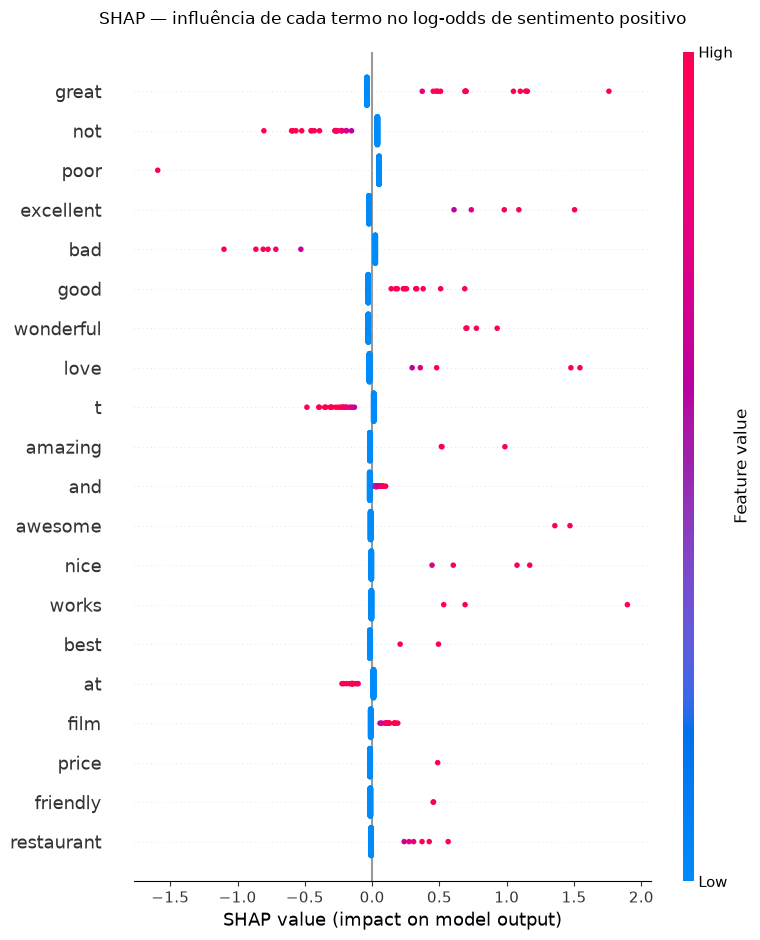

In [11]:
import shap

tfidf_ajustado = melhor_modelo.named_steps["tfidf"]
clf_ajustado = melhor_modelo.named_steps["clf"]
nomes_atributos = tfidf_ajustado.get_feature_names_out()

coeficientes = clf_ajustado.feature_log_prob_[1] - clf_ajustado.feature_log_prob_[0]
intercepto = clf_ajustado.class_log_prior_[1] - clf_ajustado.class_log_prior_[0]

X_dev_tfidf = tfidf_ajustado.transform(X_dev).toarray()
X_test_tfidf = tfidf_ajustado.transform(X_test).toarray()

rng = np.random.default_rng(42)
fundo = X_dev_tfidf[rng.choice(X_dev_tfidf.shape[0], size=100, replace=False)]
indices_shap = rng.choice(X_test_tfidf.shape[0], size=min(200, X_test_tfidf.shape[0]), replace=False)
X_shap = pd.DataFrame(X_test_tfidf[indices_shap], columns=nomes_atributos)

explainer = shap.LinearExplainer((coeficientes, intercepto), fundo)
valores_shap = explainer(X_shap)

shap.summary_plot(
    valores_shap.values, X_shap, feature_names=nomes_atributos,
    plot_type="dot", max_display=20, show=False,
)
plt.title("SHAP — influência de cada termo no log-odds de sentimento positivo", pad=20)
plt.tight_layout(); plt.show()

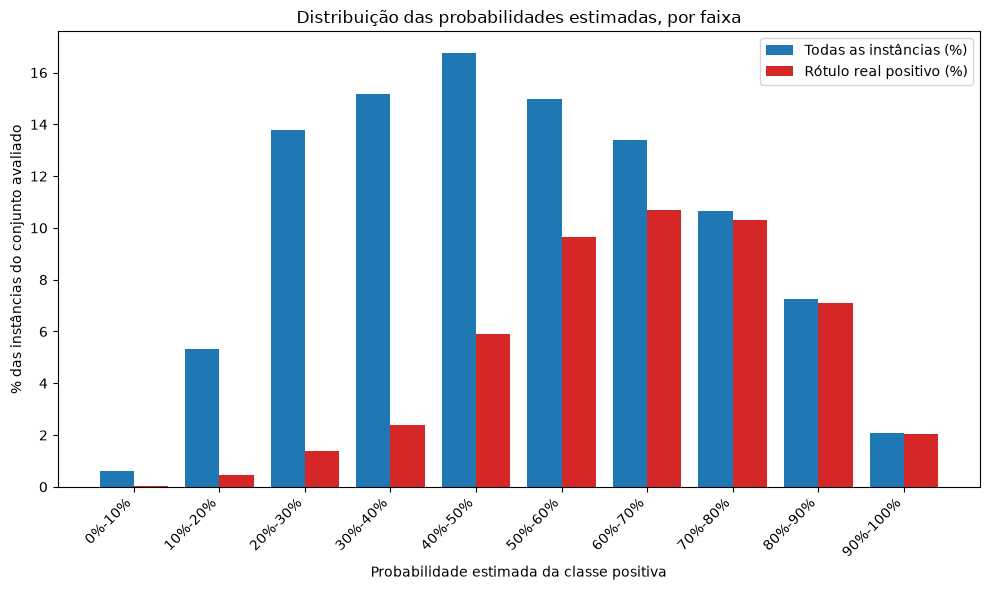

      faixa  contagem_total  pct_total  contagem_positivos  \
0    0%-10%              14   0.622222                   1   
1   10%-20%             120   5.333333                  10   
2   20%-30%             310  13.777778                  31   
3   30%-40%             341  15.155556                  54   
4   40%-50%             377  16.755556                 133   
5   50%-60%             337  14.977778                 217   
6   60%-70%             301  13.377778                 241   
7   70%-80%             240  10.666667                 232   
8   80%-90%             163   7.244444                 160   
9  90%-100%              47   2.088889                  46   

   pct_positivos_na_faixa  
0                7.142857  
1                8.333333  
2               10.000000  
3               15.835777  
4               35.278515  
5               64.391691  
6               80.066445  
7               96.666667  
8               98.159509  
9               97.872340  


In [14]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from parte1_grafico_pontos_corte.histograma_grafico_e_faixas import plot_corte

proba_oof = cross_val_predict(melhor_modelo, X_dev, y_dev, cv=validacao, method="predict_proba")[:, 1]

fig, ax, tabela_validacao, _ = plot_corte(y_dev.values, proba_oof, bin_width=10)
plt.show()
print(tabela_validacao)

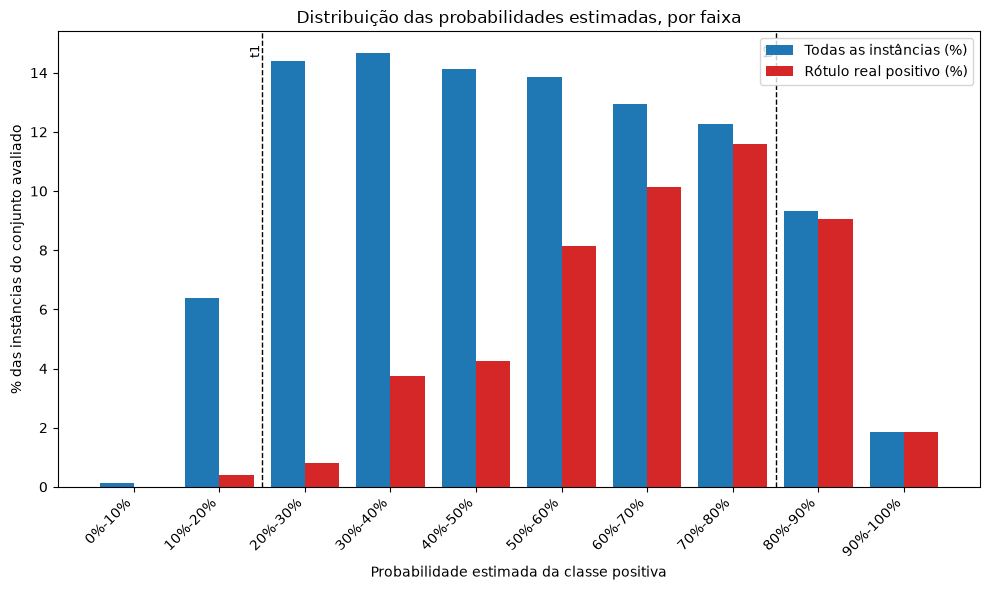

      faixa  contagem_total  pct_total  contagem_positivos  \
0    0%-10%               1   0.133333                   0   
1   10%-20%              48   6.400000                   3   
2   20%-30%             108  14.400000                   6   
3   30%-40%             110  14.666667                  28   
4   40%-50%             106  14.133333                  32   
5   50%-60%             104  13.866667                  61   
6   60%-70%              97  12.933333                  76   
7   70%-80%              92  12.266667                  87   
8   80%-90%              70   9.333333                  68   
9  90%-100%              14   1.866667                  14   

   pct_positivos_na_faixa  
0                0.000000  
1                6.250000  
2                5.555556  
3               25.454545  
4               30.188679  
5               58.653846  
6               78.350515  
7               94.565217  
8               97.142857  
9              100.000000  
Falsos ne

In [18]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from parte1_grafico_pontos_corte.histograma_grafico_e_faixas import plot_corte

fig, ax, tabela_validacao, metricas = plot_corte(y_test.values, y_prob, bin_width=10, t1=20.0, t2=80.0)
plt.show()
print(tabela_validacao)

print(f"Falsos negativos (positivos perdidos): {metricas['proporcao_positivos_em_negativo_automatico']:.2f}%")
print(f"Falsos positivos (negativos perdidos): {metricas['proporcao_negativos_em_positivo_automatico']:.2f}%")